# Demo

This demo walks through:
1. Making a layer/gate set for an IBM device.
2. Creating a 2-local Pauli-Lindblad model based on the device topology.
3. Build "vanilla" Pauli-Lindblad learning experiments.
4. Running the experiments.
5. Fitting the model and getting noise maps.

In [1]:
from qiskit_ibm_runtime import Executor, QiskitRuntimeService

runtime = QiskitRuntimeService(name="foo")
backend = runtime.backend("ibm_marrakesh")
executor = Executor(backend)

qiskit_runtime_service.__init__:WARNING:2026-05-13 14:27:21,341: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (internal, premium), the available account instances are: engine-premium-eu, engine-internal-eu, engine-internal-us, engine-premium-us. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-13 14:27:21,341: Using instance: engine-premium-us, plan: premium


## 1. Build a gate set with a single layer on a ring of qubits

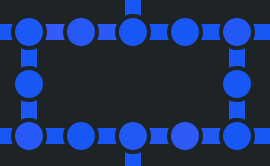

In [5]:
from qiskit_noise_learning.gate_sets import QiskitGateSet

qubit_subset = [*range(25, 30), *range(37, 39), *range(45, 50)]
gate_set = QiskitGateSet(backend.num_qubits, target=backend.target, qubit_subset=qubit_subset)

layer_1_pairs = [(25, 26), (27, 28), (29, 38), (37, 45), (46, 47), (48, 49)]

with gate_set.build_new_gate("layer_1") as builder:
    for pair in layer_1_pairs:
        builder.circuit.cz(*pair)

In [6]:
gate_set.draw()

## 2. Create a 2-local Pauli-Lindblad model.

In [7]:
from qiskit_noise_learning.models import PauliLindbladModel

pauli_lindblad_model = PauliLindbladModel.k_local(
    gate_set, k=2
)  # , noise_site={"layer_1": "after"})

## 3. Build learning experiments

In [8]:
from qiskit_noise_learning.experiment_builder import (
    ExperimentBuilder,
    standard_vanilla_pattern_generator,
)

experiment_builder = ExperimentBuilder(fidelity_model=pauli_lindblad_model)

experiment_builder.add_path_patterns(
    standard_vanilla_pattern_generator(
        experiment_builder.gate_set["P"],
        experiment_builder.gate_set["M"],
        experiment_builder.gate_set["layer_1"],
        pauli_lindblad_model.generators["layer_1"],
        experiment_builder.gate_set.coupling_map,
    ),
    attempt_instruction_merge=True,
)
experiment_builder.complete()

print(f"Number of path patterns: {len(experiment_builder.path_patterns)}")
print(f"Number of instruction patterns: {len(experiment_builder.instruction_patterns)}")

Number of path patterns: 108
Number of instruction patterns: 9


## 4. Run experiments

In [9]:
# generate instruction sequences
depths = [0, 2, 16, 32, 64, 128]
instruction_sequences = experiment_builder.generate_instruction_sequences(depths)

print(f"Number of instruction sequences: {len(instruction_sequences)}")

Number of instruction sequences: 54


Number of template circuits: 6
Depth 2 template circuit:


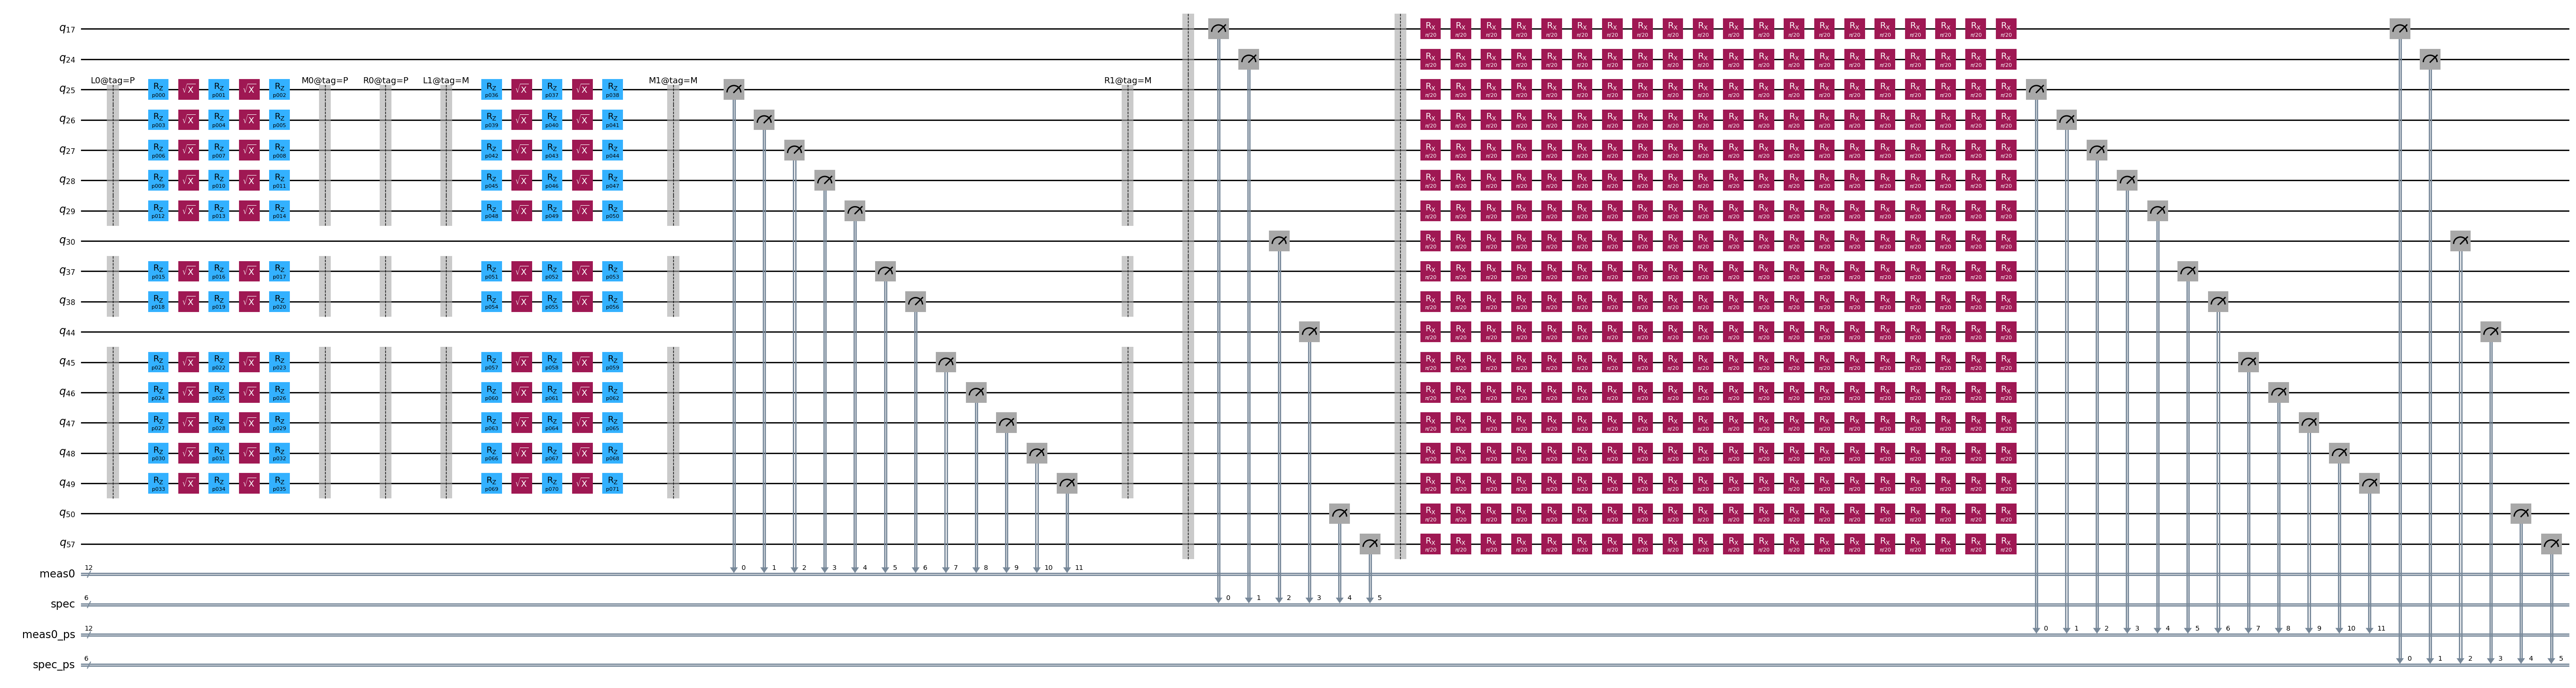

In [10]:
from qiskit.transpiler import PassManager
from qiskit_addon_utils.noise_management.post_selection.transpiler.passes import (
    AddPostSelectionMeasures,
    AddSpectatorMeasures,
)

from qiskit_noise_learning.circuit_generator import ExecutorCircuitGenerator

# build post selection pass manager
post_selection_pm = PassManager(
    [
        AddSpectatorMeasures(backend.coupling_map),
        AddPostSelectionMeasures(x_pulse_type="rx"),
    ]
)

# generate inputs to executor
num_rand = 50
circuit_generator = ExecutorCircuitGenerator(
    gate_set, num_randomizations=num_rand, pass_manager=post_selection_pm
)
samplex_items, data_mapper = circuit_generator.generate(instruction_sequences)

print(f"Number of template circuits: {len(samplex_items)}")
print("Depth 2 template circuit:")
samplex_items[0].circuit.draw("mpl", idle_wires=False, fold=False)

In [11]:
# run program and collect raw data
from qiskit_ibm_runtime import QuantumProgram

num_shots = 20
qp = QuantumProgram(num_shots, samplex_items)
# job = executor.run(qp)
# job = runtime.job("d82e9entjchs73bnvi90")  # 2 cnots
job = runtime.job("d82cbko0bvlc73d24hsg")  # full job, noise before
# job = runtime.job("d82drafoha1c73blf2tg")  # full job, noise after
raw_data = circuit_generator.collect(job.result(), data_mapper)

/Users/danielpuzzuoli/Documents/software_projects/qiskit-noise-learning/qiskit_noise_learning/circuit_generator/executor_circuit_generator.py:144: UserWarning: no explicit representation of timezones available for np.datetime64
  chunk_start = np.array(chunk_timing.start, dtype="datetime64[us]")
/Users/danielpuzzuoli/Documents/software_projects/qiskit-noise-learning/qiskit_noise_learning/circuit_generator/executor_circuit_generator.py:145: UserWarning: no explicit representation of timezones available for np.datetime64
  chunk_stop = np.array(chunk_timing.stop, dtype="datetime64[us]")


## 5. Analyzing the data

In [12]:
from qiskit_noise_learning.analysis import (
    ComputeObservables,
    CurveFitObservables,
    FlipPostSelect,
    NNLSSolve,
)

analyzer = FlipPostSelect() + ComputeObservables() + CurveFitObservables() + NNLSSolve()

In [13]:
from qiskit_noise_learning.analysis import Fit
from qiskit_noise_learning.data import RawData
from qiskit_noise_learning.sequences import Path

fit = Fit(
    model=pauli_lindblad_model,
    paths=[Path(p, d) for p in experiment_builder.path_patterns for d in depths],
)
fit[RawData] = raw_data

In [14]:
fit = analyzer.run(fit)

In [15]:
from qiskit.quantum_info import PauliLindbladMap

from qiskit_noise_learning.models.pauli_lindblad_model import GeneratorIndex


def get_conj_data(fit):
    fid_model = fit.model

    model_dataset = fit.model_data.dataset
    pl_map: PauliLindbladMap = fid_model.to_pauli_lindblad_maps(fit.model_data)["layer_1"]

    conj_fidelities = []
    conj_pairs = []
    conj_rates = []
    for gen in fid_model.generators["layer_1"]:
        out = fid_model.gate_set["layer_1"].clifford_propagate(gen)
        if out != gen and out in fid_model.generators["layer_1"] and (gen, out) not in conj_pairs:
            conj_pairs.append((out, gen))
            conj_fidelities.append((pl_map.pauli_fidelity(out), pl_map.pauli_fidelity(gen)))
            gen_rate = model_dataset.sel(
                {"parameter": model_dataset["parameter"] == GeneratorIndex("layer_1", gen)}
            )["parameter_values"].data[0]
            out_rate = model_dataset.sel(
                {"parameter": model_dataset["parameter"] == GeneratorIndex("layer_1", out)}
            )["parameter_values"].data[0]
            conj_rates.append((out_rate, gen_rate))

    return conj_pairs, conj_fidelities, conj_rates

In [16]:
conj_pairs, conj_fids, conj_rates = get_conj_data(fit)

In [17]:
conj_fids

[(0.9663177375633234, 0.9562354247048684),
 (0.9596207444749191, 0.9493730523582131),
 (0.9803203463662515, 0.9771054795939458),
 (0.9777846037303762, 0.9748195524411797),
 (0.9925371017991054, 0.9913942728636773),
 (0.9929990703393193, 0.9918557094832063),
 (0.9937551649349031, 0.9974393308360114),
 (0.9949007153867311, 0.9985891282070622),
 (0.9917463446324146, 0.9870215488350021),
 (0.9929669560681919, 0.9882363451348696),
 (0.9936152417693087, 0.9862620023835774),
 (0.9957824299743795, 0.988413152334608),
 (0.9870597025819532, 0.9904940326611896),
 (0.988573821405568, 0.990796000552601),
 (0.9914581240415391, 0.9929774823627736),
 (0.990042305186576, 0.9929711774812571),
 (0.994876773166336, 0.9957320590025488),
 (0.9941364421119079, 0.9959498594601088),
 (0.9960748993113772, 0.9932590818828068),
 (0.9965203108524584, 0.9927466290684005),
 (0.986018498904749, 0.9859237397206864),
 (0.9879449968168289, 0.9874827208349588),
 (0.986728354471618, 0.985685181189405),
 (0.988331895243613

In [18]:
from qiskit_noise_learning.analysis.symmetrize import SymmetrizeFidelities3

fit2 = SymmetrizeFidelities3().run(fit)

# fit2 = SymmetrizeFidelities().run(fit)

In [19]:
sym_conj_pairs, sym_conj_fids, sym_conj_rates = get_conj_data(fit2)

In [20]:
sym_conj_fids

[(0.9612633625488449, 0.9612633625488449),
 (0.9544831456282582, 0.9544831456282582),
 (0.9787115929587732, 0.9787115929587732),
 (0.9763009524692279, 0.9763009524692279),
 (0.9919655227518474, 0.9919655227518474),
 (0.9924272252551165, 0.9924272252551165),
 (0.9955955437463047, 0.9955955437463047),
 (0.996743215693299, 0.996743215693299),
 (0.989381126326219, 0.989381126326219),
 (0.990598826722769, 0.990598826722769),
 (0.9899317945930622, 0.9899317945930622),
 (0.9920909487795927, 0.9920909487795927),
 (0.9887753765581712, 0.9887753765581712),
 (0.9896842872854141, 0.9896842872854141),
 (0.9922175123826862, 0.9922175123826862),
 (0.9915056598614919, 0.9915056598614919),
 (0.9953043242138193, 0.9953043242138193),
 (0.9950427376778986, 0.9950427376778986),
 (0.9946659941792158, 0.9946659941792158),
 (0.9946316802701253, 0.9946316802701253),
 (0.9859711181743346, 0.9859711181743346),
 (0.9877138317812335, 0.9877138317812335),
 (0.9862066299017058, 0.9862066299017058),
 (0.9876256474828

In [25]:
import numpy as np

np.array([np.prod(x) for x in conj_fids]) - np.array([np.prod(x) for x in sym_conj_fids])

array([ 1.11022302e-16,  1.11022302e-16,  0.00000000e+00,  0.00000000e+00,
       -1.11022302e-16,  1.11022302e-16,  0.00000000e+00, -1.11022302e-16,
        0.00000000e+00,  0.00000000e+00,  1.11022302e-16,  0.00000000e+00,
        1.11022302e-16,  0.00000000e+00,  0.00000000e+00,  1.11022302e-16,
       -1.11022302e-16, -1.11022302e-16,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  1.11022302e-16,  1.11022302e-16,  0.00000000e+00,
        1.11022302e-16,  0.00000000e+00, -1.11022302e-16, -1.11022302e-16,
        0.00000000e+00,  0.00000000e+00, -1.11022302e-16,  0.00000000e+00,
       -1.11022302e-16,  1.11022302e-16,  0.00000000e+00,  1.11022302e-16])

In [22]:
conj_rates

[(np.float64(0.0029697456320630557), np.float64(0.0)),
 (np.float64(0.0), np.float64(0.0)),
 (np.float64(0.0057223654006909215), np.float64(0.0)),
 (np.float64(0.002424110518017358), np.float64(0.0)),
 (np.float64(0.0), np.float64(0.0)),
 (np.float64(0.0), np.float64(0.0)),
 (np.float64(0.0), np.float64(0.0)),
 (np.float64(0.0006158985010994931), np.float64(0.0)),
 (np.float64(0.0015893549120516855), np.float64(0.0)),
 (np.float64(0.002164505553116082), np.float64(0.0)),
 (np.float64(0.0006491907106873802), np.float64(0.0)),
 (np.float64(0.0020275010059114316), np.float64(0.0)),
 (np.float64(0.00045873240923647576), np.float64(0.0)),
 (np.float64(0.0014340595541695459), np.float64(0.0)),
 (np.float64(0.0), np.float64(0.0008567211756606265)),
 (np.float64(0.0), np.float64(0.0005354086378303734)),
 (np.float64(0.0009738744012462982), np.float64(0.0)),
 (np.float64(0.0007999408553092673), np.float64(0.0)),
 (np.float64(0.0), np.float64(0.0002577966946295883)),
 (np.float64(0.0003666908903

In [26]:
max(np.abs(a - b) for a, b in sym_conj_fids)

np.float64(0.0)

In [27]:
map0 = pauli_lindblad_model.to_pauli_lindblad_maps(fit.model_data)["layer_1"]
map1 = pauli_lindblad_model.to_pauli_lindblad_maps(fit2.model_data)["layer_1"]

In [28]:
gate = pauli_lindblad_model.gate_set["layer_1"]

fids0 = []
fids1 = []
for pauli in map0.generators():
    if pauli != gate.clifford_propagate(pauli):
        continue
    fids0.append(map0.pauli_fidelity(pauli))
    fids1.append(map1.pauli_fidelity(pauli))

In [32]:
np.array(fids0) - np.array(fids1)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0.])

In [31]:
fids1

[0.9781450123446913,
 0.9697746687374034,
 0.977689954291801,
 0.9924412792473476,
 0.9912985606441022,
 0.9865722694477536,
 0.9967161885129043,
 0.9870748979887485,
 0.9934312403710605,
 0.9839058990255025,
 0.9964188492743568,
 0.9916717931173118,
 0.9957447349939299,
 0.9923445735671379,
 0.9964356953319614,
 0.9874068506676839,
 0.9963063759496826,
 0.9950005679171137,
 0.9911970173671097,
 0.9849361690397446,
 0.9861316789791735,
 0.9895300643243227,
 0.9940862901188018,
 0.9986893509224768]

In [21]:
from qiskit_noise_learning.math import IndexedMatrix
from qiskit_noise_learning.sequences import FidelityIndex

# construct rate -> fidelity map
gate = pauli_lindblad_model.gate_set["layer_1"]
generators = pauli_lindblad_model.generators["layer_1"]

fidelities = [FidelityIndex(gate, pauli=x) for x in generators]
H = IndexedMatrix()
H.add_rows(
    rows=[pauli_lindblad_model.row_from_fidelity(x) for x in fidelities], row_indices=fidelities
)

In [22]:
H.column_index_map

{GeneratorIndex(gate_name='layer_1', generator=<QubitSparsePauli on 156 qubits: X_25>): 0,
 GeneratorIndex(gate_name='layer_1', generator=<QubitSparsePauli on 156 qubits: Y_25>): 1,
 GeneratorIndex(gate_name='layer_1', generator=<QubitSparsePauli on 156 qubits: Z_26 X_25>): 2,
 GeneratorIndex(gate_name='layer_1', generator=<QubitSparsePauli on 156 qubits: Z_26 Y_25>): 3,
 GeneratorIndex(gate_name='layer_1', generator=<QubitSparsePauli on 156 qubits: X_26 X_25>): 4,
 GeneratorIndex(gate_name='layer_1', generator=<QubitSparsePauli on 156 qubits: X_26 Y_25>): 5,
 GeneratorIndex(gate_name='layer_1', generator=<QubitSparsePauli on 156 qubits: Y_26 X_25>): 6,
 GeneratorIndex(gate_name='layer_1', generator=<QubitSparsePauli on 156 qubits: Y_26 Y_25>): 7,
 GeneratorIndex(gate_name='layer_1', generator=<QubitSparsePauli on 156 qubits: Z_25>): 8,
 GeneratorIndex(gate_name='layer_1', generator=<QubitSparsePauli on 156 qubits: X_26>): 9,
 GeneratorIndex(gate_name='layer_1', generator=<QubitSparseP

Check percentage of shots removed by post-selection.

In [23]:
fit.raw_data.datatree["0"]["data_mask"].mean()

<xarray.DataArray 'data_mask' ()> Size: 8B
array(0.13681481)

In [24]:
from matplotlib import pyplot as plt

from qiskit_noise_learning.analysis import AverageObservables

# compute observables and plot empirical decays

averaged_data = AverageObservables().run(fit).averaged_data


def _sorted_data(averaged_data):
    dataset = averaged_data.dataset

    sorted_data = {}
    for path_pattern, depth, val in zip(
        dataset["path_pattern"].data, dataset["depth"].data, dataset["observables"].data
    ):
        if depth < 0:
            continue
        this_data = sorted_data.setdefault(path_pattern, ([], []))
        this_data[0].append(val)
        this_data[1].append(depth)

    return {k: v for k, v in sorted_data.items() if len(v[0]) > 1}  # filter on decays


def plot(averaged_data, subsets, num_cols=3):
    sorted_data = _sorted_data(averaged_data)

    plots = {}
    for subset in subsets:
        plots[subset] = []
        for path_pattern in sorted_data.keys():
            if set(subset).issuperset(path_pattern.start_fragment[0].out_bit_indices):
                plots[subset].append(path_pattern)

    num_figs = len(plots)
    num_rows = num_figs // num_cols

    fig, axs = plt.subplots(num_rows, num_cols)
    flag = True
    for ax, (subset, path_patterns) in zip(axs.flat, plots.items()):
        ax.set_title(f"{subset}")
        for path_pattern in path_patterns:
            this_data = sorted_data[path_pattern]
            label = fidelity_label(path_pattern, [s for s in subset]) if flag else None
            ax.plot(
                this_data[1],
                this_data[0],
                "--",
                label=label,
            )
        flag = False

    fig.legend(bbox_to_anchor=(1.15, 0), loc="lower right")
    plt.tight_layout()


def fidelity_label(path_pattern, subset):
    return (
        "$f_{"
        + "} f_{".join(
            "".join(str(fid.pauli.to_pauli()[subset])) for fid in path_pattern.repeatable_fragment
        )
        + "} $"
    )


plot(averaged_data, layer_1_pairs)

ValueError: Number of rows must be a positive integer, not 0

<Figure size 640x480 with 0 Axes>

In [ ]:
model_data = fit.model_data
noise_maps = pauli_lindblad_model.to_pauli_lindblad_maps(model_data)

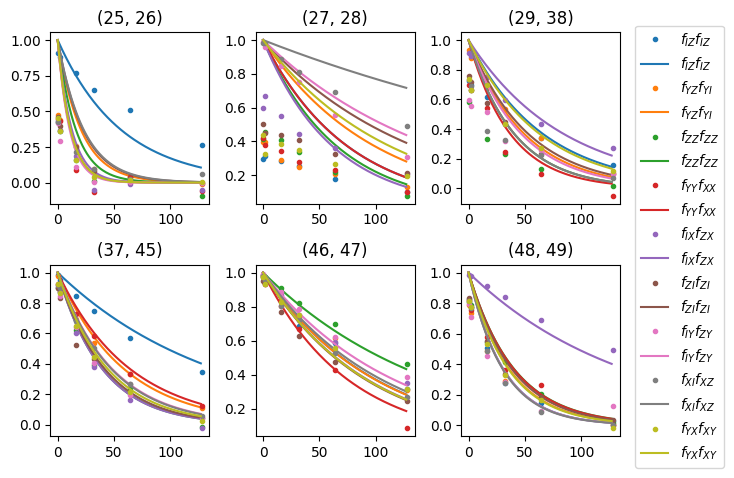

In [ ]:
# plot decays v.s. model prediction
# Note: plotting model decays without prefactors from SPAM
import matplotlib.colors as mcolors
import numpy as np


def plot_with_model_decay(
    pauli_lindblad_map, observable_data, subsets, num_cols=3, start_idx=None, end_idx=None
):
    sorted_data = _sorted_data(observable_data)

    plots = {}
    for subset in subsets:
        plots[subset] = []
        for path_pattern in sorted_data.keys():
            if set(subset).issuperset(path_pattern.start_fragment[0].out_bit_indices):
                plots[subset].append(path_pattern)

    num_figs = len(plots)
    num_rows = num_figs // num_cols

    fig, axs = plt.subplots(num_rows, num_cols)
    flag = True
    for ax, (subset, path_patterns) in zip(axs.flat, plots.items()):
        ax.set_title(f"{subset}")
        if start_idx is None:
            start_idx = 0
        if end_idx is None:
            end_idx = len(path_patterns)
        for color_code, path_pattern in list(zip(mcolors.TABLEAU_COLORS.values(), path_patterns))[
            start_idx:end_idx
        ]:
            this_data = sorted_data[path_pattern]
            label = fidelity_label(path_pattern, [s for s in subset]) if flag else None
            ax.plot(
                this_data[1],
                this_data[0],
                ".",
                label=label,
                color=color_code,
            )
            pauli_in = path_pattern.repeatable_fragment[0].transition[0]
            fidelity_in = pauli_lindblad_map.pauli_fidelity(pauli_in)
            pauli_out = path_pattern.repeatable_fragment[0].transition[1]
            fidelity_out = pauli_lindblad_map.pauli_fidelity(pauli_out)
            ax.plot(
                np.arange(max(this_data[1])),
                (fidelity_in * fidelity_out) ** (np.arange(max(this_data[1]))),
                "-",
                label=label,
                color=color_code,
            )
        flag = False

    fig.legend(bbox_to_anchor=(1.15, 0), loc="lower right")
    plt.tight_layout()


# k = 8
plot_with_model_decay(
    noise_maps["layer_1"], averaged_data, layer_1_pairs
)  # , start_idx=k, end_idx=k + 1)

## 7. Investigating results

### 7.1 Comparison to `NoiseLearnerV3`

In [ ]:
from qiskit.circuit import BoxOp, CircuitInstruction, QuantumRegister, Qubit
from qiskit_ibm_runtime.noise_learner_v3.noise_learner_v3 import (
    NoiseLearnerV3,
    NoiseLearnerV3Options,
)
from samplomatic.annotations import Twirl

options = NoiseLearnerV3Options(
    shots_per_randomization=num_shots, num_randomizations=num_rand, layer_pair_depths=depths
)

noise_learner = NoiseLearnerV3(mode=backend, options=options)

gate = gate_set["layer_1"]
qreg = QuantumRegister(backend.target.num_qubits, "q")
circuit_instruction = CircuitInstruction(
    BoxOp(gate.circuit, annotations=[Twirl()]),
    [Qubit(register=qreg, index=x) for x in gate.qubit_idxs],
)

# job = noise_learner.run([circuit_instruction])
job = runtime.job("d7h96gq2khts739pftf0")
result = job.result()

# map onto qubit subset (noise learner returns map with virtual indices)
# confused about indices...
noise_learner_map = (
    result[0].to_pauli_lindblad_map().apply_layout(sorted(gate.qubit_idxs), num_qubits=156)
)

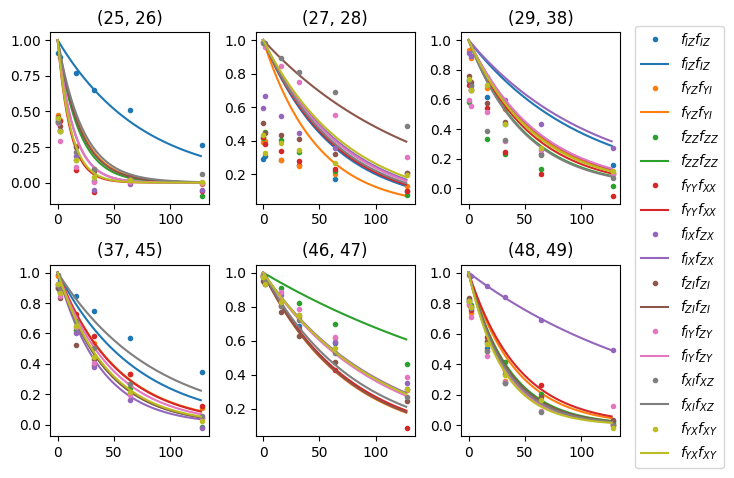

In [ ]:
plot_with_model_decay(noise_learner_map, averaged_data, layer_1_pairs)